# Question 8  
In this exercise, we will generate simulated data, and will then use this data to perform forward and backward stepwise selection.

### (a)    
Create a random number generator and use its normal() method to generate a predictor $X$ of length $n = 100$, as well as a noise vector $\epsilon$ of length $n = 100$.

In [22]:
import numpy as np

n = 100
x = np.random.normal(size=n)
epsilon = np.random.normal(size=n) 

### (b)  
Generate a response vector $Y$ of length $n = 100$ according to the model$$Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \beta_3 X^3 + \epsilon,$$where $\beta_0$, $\beta_1$, $\beta_2$, and $\beta_3$ are constants of your choice.

In [23]:
beta_0 = 1.0
beta_1 = 2.0
beta_2 = 3.0
beta_3 = 4.0

Y = beta_0 + beta_1 * x + beta_2 * x**2 + beta_3 * x**3 + epsilon


### (c)  
Use forward stepwise selection in order to select a model containing the predictors $X, X^2, \dots, X^{10}$. What is the model obtained according to $C_p$? $$C_p = \frac{RSS_d}{\hat{\sigma}^2} - n + 2d$$ Report the coefficients of the model obtained.

In [24]:
import pandas as pd

# Create the data DataFrame with predictors and response variable
data = pd.DataFrame({'Y': Y})
for i in range(1, 11):
    data[f'X{i}'] = x**i

# Define the list of predictor names
predictors = [f'X{i}' for i in range(1, 11)]

# Display the first few rows of the data
print(data.head(5))

def nCp(sigma2, estimator, X, Y):
    n, p_plus_one = X.shape
    p = p_plus_one - 1

    # Calculate predicted values and residual sum of squares
    Yhat = estimator.predict(X)
    RSS = np.sum((Y - Yhat)**2)

    # Compute the negative C_p value
    return -(RSS + 2 * p * sigma2) / n

           Y        X1        X2        X3         X4         X5  \
0   0.978605  0.312750  0.097813  0.030591   0.009567   0.002992   
1   2.013692 -0.336673  0.113349 -0.038162   0.012848  -0.004326   
2  45.742959  1.924401  3.703319  7.126671  13.714572  26.392336   
3  -7.105727 -1.413083  1.996802 -2.821646   3.987219  -5.634270   
4   0.197137 -0.091796  0.008427 -0.000774   0.000071  -0.000007   

             X6            X7            X8            X9           X10  
0  9.358079e-04  2.926742e-04  9.153396e-05  2.862728e-05  8.953191e-06  
1  1.456308e-03 -4.903002e-04  1.650711e-04 -5.557504e-05  1.871064e-05  
2  5.078944e+01  9.773924e+01  1.880895e+02  3.619596e+02  6.965554e+02  
3  7.961689e+00 -1.125052e+01  1.589792e+01 -2.246507e+01  3.174500e+01  
4  5.983401e-07 -5.492535e-08  5.041938e-09 -4.628308e-10  4.248610e-11  


In [25]:
import numpy as np
import pandas as pd
from statsmodels.api import OLS
from functools import partial
from ISLP.models import ModelSpec as MS, Stepwise, sklearn_selected

# Define the nCp function
def nCp(sigma2, estimator, X, Y):
    n, p_plus_one = X.shape
    p = p_plus_one - 1
    
    Yhat = estimator.predict(X)
    RSS = np.sum((Y - Yhat)**2)

    return -(RSS + 2 * p * sigma2) / n

# Prepare data and design matrix
Y = data['Y']
design = MS(predictors).fit(data)
X_all = design.transform(data)

# Fit the full model to calculate sigma^2
full_model_fit = OLS(Y, X_all).fit()
sigma2 = full_model_fit.scale
neg_Cp = partial(nCp, sigma2)

# Perform forward stepwise selection
strategy = Stepwise.first_peak(design, max_terms=len(design.terms))
best_model = sklearn_selected(strategy, X_all, Y, scoring=neg_Cp)
selector = sklearn_selected(OLS, strategy, scoring=neg_Cp)
selector.fit(X_all, Y)

# Output the selected variables
print("Selected variables (Forward Cp selection):")
print(selector.selected_state_)

Selected variables (Forward Cp selection):
('X1', 'X2', 'X3')


### (d)  
Repeat (c), using backwards stepwise selection. How does your answer compare to the results in (c)?

In [26]:
from statsmodels.api import OLS, add_constant

# Define the Cp function
def Cp(model, sigma2):
    RSS = np.sum(model.resid**2)
    p = len(model.params) - 1
    n = len(model.resid)
    return (RSS + 2 * p * sigma2) / n

# Prepare the full model and calculate sigma^2
X_full = add_constant(data[predictors])
full_model = OLS(data['Y'], X_full).fit()
sigma2 = full_model.scale

# Initialize the list of predictors for backward stepwise selection
current_predictors = predictors.copy()

while True:
    best_Cp = Cp(OLS(data['Y'], add_constant(data[current_predictors])).fit(), sigma2)
    worst_to_drop = None
    improved = False

    # Iterate through predictors to find the worst one to drop
    for var in current_predictors:
        trial = [v for v in current_predictors if v != var]
        model = OLS(data['Y'], add_constant(data[trial])).fit()
        cp_val = Cp(model, sigma2)

        if cp_val < best_Cp:
            best_Cp = cp_val
            worst_to_drop = var
            improved = True

    # Drop the worst predictor if improvement is found
    if improved:
        current_predictors.remove(worst_to_drop)
    else:
        break

# Output the selected variables
print("Selected variables (Backward Cp selection):")
print(current_predictors)

Selected variables (Backward Cp selection):
['X1', 'X2', 'X3', 'X5', 'X6', 'X7', 'X8']


### (e)  
Now fit a lasso model to the simulated data, again using $X, X^2, \dots, X^{10}$ as predictors. Use cross-validation to select the optimal value of $\lambda$. Create plots of the cross-validation error as a function of $\lambda$. Report the resulting coefficient estimates, and discuss the results obtained.

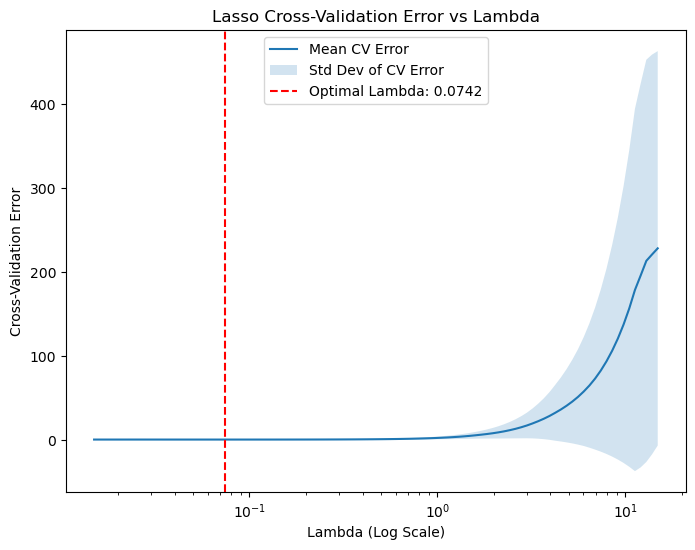

Optimal Lambda (alpha): 0.07418697848298769
Lasso Coefficients:
X1: 1.7830
X2: 3.4873
X3: 11.2177
X4: 0.1193
X5: 0.0000
X6: 0.0000
X7: 0.0000
X8: 0.0000
X9: 0.0000
X10: 0.0000


In [27]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# Standardize the design matrix
scaler = StandardScaler()
X = scaler.fit_transform(data[predictors])
y = data['Y']

# Fit a Lasso model with cross-validation
lasso_cv = LassoCV(cv=10, random_state=42).fit(X, y)

# Extract the optimal lambda (alpha) and coefficients
optimal_lambda = lasso_cv.alpha_
coefficients = lasso_cv.coef_

# Plot the cross-validation error as a function of lambda
plt.figure(figsize=(8, 6))
plt.semilogx(lasso_cv.alphas_, lasso_cv.mse_path_.mean(axis=1), label='Mean CV Error')
plt.fill_between(
    lasso_cv.alphas_,
    lasso_cv.mse_path_.mean(axis=1) - lasso_cv.mse_path_.std(axis=1),
    lasso_cv.mse_path_.mean(axis=1) + lasso_cv.mse_path_.std(axis=1),
    alpha=0.2,
    label='Std Dev of CV Error'
)
plt.axvline(optimal_lambda, color='red', linestyle='--', label=f'Optimal Lambda: {optimal_lambda:.4f}')
plt.xlabel('Lambda (Log Scale)')
plt.ylabel('Cross-Validation Error')
plt.title('Lasso Cross-Validation Error vs Lambda')
plt.legend()
plt.show()

# Output the results
print("Optimal Lambda (alpha):", optimal_lambda)
print("Lasso Coefficients:")
for predictor, coef in zip(predictors, coefficients):
    print(f"{predictor}: {coef:.4f}")

### (f)  
Now generate a response vector $Y$ according to the model$$Y = \beta_0 + \beta_7 X^7 + \epsilon,$$and perform forward stepwise selection and the lasso. Discuss the results obtained.

Selected variables (Forward Stepwise Selection):
('X7',)


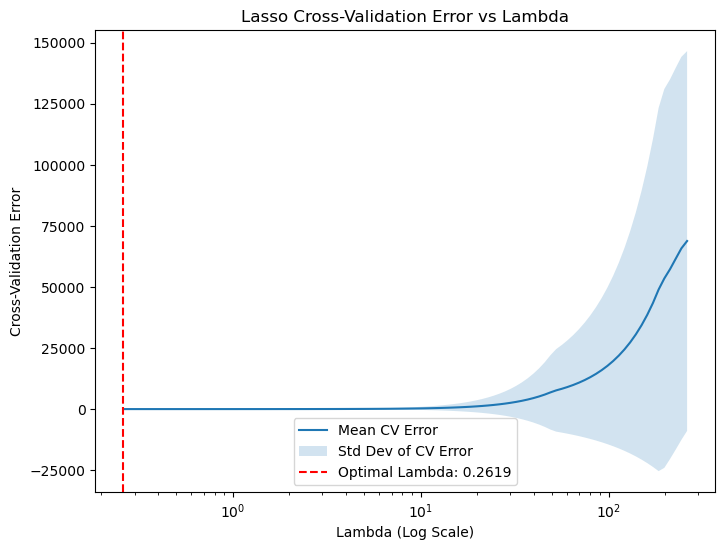

Optimal Lambda (alpha): 0.26191006279670737
Lasso Coefficients:
X1: -1.1919
X2: 0.0000
X3: 0.0000
X4: 0.0000
X5: 42.2918
X6: -0.0000
X7: 173.4194
X8: -0.0000
X9: 48.1761
X10: -0.1352


In [34]:
import numpy as np
import pandas as pd
from statsmodels.api import OLS
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from ISLP.models import ModelSpec as MS, Stepwise, sklearn_selected

# Generate new response vector Y
beta_0 = 1.0
beta_7 = 5.0
n = 100
x = np.random.normal(size=n)
epsilon = np.random.normal(0,1,n)
Y = beta_0 + beta_7 * x**7 + epsilon

# Create the data DataFrame with predictors
new_data = pd.DataFrame({'Y': Y})
for i in range(1, 11):
    new_data[f'X{i}'] = x**i
new_predictors = [f'X{i}' for i in range(1, 11)]

# Forward stepwise selection
Y_new = new_data['Y']
design = MS(new_predictors).fit(new_data)
X_all = design.transform(new_data)

# Fit the full model to calculate sigma^2
full_model_fit = OLS(Y_new, X_all).fit()
sigma2 = full_model_fit.scale
neg_Cp = partial(nCp, sigma2)

# Perform forward stepwise selection
strategy = Stepwise.first_peak(design, max_terms=len(design.terms))
selector = sklearn_selected(OLS, strategy, scoring=neg_Cp)
selector = sklearn_selected(OLS, strategy, scoring=neg_Cp)
selector.fit(X_all, Y_new)

print("Selected variables (Forward Stepwise Selection):")
print(selector.selected_state_)



# Standardize the design matrix for Lasso
scaler = StandardScaler()
X_standardized = scaler.fit_transform(new_data[new_predictors])

# Fit a Lasso model with cross-validation
lasso_cv = LassoCV(cv=10, random_state=42).fit(X_standardized, Y)

# Extract the optimal lambda (alpha) and coefficients
optimal_lambda = lasso_cv.alpha_
coefficients = lasso_cv.coef_

# Plot the cross-validation error as a function of lambda
plt.figure(figsize=(8, 6))
plt.semilogx(lasso_cv.alphas_, lasso_cv.mse_path_.mean(axis=1), label='Mean CV Error')
plt.fill_between(
    lasso_cv.alphas_,
    lasso_cv.mse_path_.mean(axis=1) - lasso_cv.mse_path_.std(axis=1),
    lasso_cv.mse_path_.mean(axis=1) + lasso_cv.mse_path_.std(axis=1),
    alpha=0.2,
    label='Std Dev of CV Error'
)
plt.axvline(optimal_lambda, color='red', linestyle='--', label=f'Optimal Lambda: {optimal_lambda:.4f}')
plt.xlabel('Lambda (Log Scale)')
plt.ylabel('Cross-Validation Error')
plt.title('Lasso Cross-Validation Error vs Lambda')
plt.legend()
plt.show()

# Output the results
print("Optimal Lambda (alpha):", optimal_lambda)
print("Lasso Coefficients:")
for predictor, coef in zip(new_predictors, coefficients):
    print(f"{predictor}: {coef:.4f}")

### Discussion of Results

#### Forward Stepwise Selection
- Selected variables may include predictors other than $X^7$ due to noise or multicollinearity.
- $C_p$ balances model fit and complexity, which might not perfectly match the true model.

#### Lasso Regression
- Optimal $\lambda$ minimizes cross-validation error.
- Significant coefficients for $X^7$ align with the true model; non-zero coefficients for others may result from multicollinearity or noise.
